TRABAJO PRÁCTICO N° 4

MÉTODOS SUPERVISADOS: REGRESIÓN & CLASIFICACIÓN USANDO LA EHP

A. Enfoque de validación

Utilicen la base respondieron. Para cada año, dividan las observaciones en
una base de prueba (test) y una de entrenamiento (train) utilizando el
comando train_test_split. La base de entrenamiento debe comprender el
70% de los datos, y la semilla a utilizar (random state instance) debe ser 444.
Establezca a desocupado como su variable dependiente en la base de
entrenamiento (vector y). El resto de las variables seleccionadas serán las
variables independientes (matriz X). Recuerden agregar la columna de unos
(1).


1. Cree una tabla de diferencia de medias entre la base de entrenamiento
y la de testeo de las características seleccionadas en su matriz X.
Comente la tabla de la diferencia de medias de sus variables entre
entrenamiento y testeo.

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

def cargar_y_preparar_datos():
    # Cargar bases (ajusta las rutas)
    t2004 = pd.read_stata('D:/Mis documentos/Estudio/Lic en economia/2do Año/Big data & machine learning/Tps/TP II/Individual_t104.dta')
    t2024 = pd.read_excel('D:/Mis documentos/Estudio/Lic en economia/2do Año/Big data & machine learning/Tps/TP II/usu_individual_T124.xlsx')
    
    # Estandarizar nombres de columnas
    t2004.columns = t2004.columns.str.upper()
    t2024.columns = t2024.columns.str.upper()
    
    # Filtrar por GBA
    t2004 = t2004[t2004['REGION'] == 'Gran Buenos Aires'].copy()
    t2024 = t2024[t2024['REGION'] == 1].copy()
    
    # Conservar columnas comunes y añadir año
    columnas_comunes = list(set(t2004.columns) & set(t2024.columns))
    t2004 = t2004[columnas_comunes].copy()
    t2024 = t2024[columnas_comunes].copy()
    t2004['ANO_EPH'] = 2004
    t2024['ANO_EPH'] = 2024
    
    # Concatenar y crear variable desocupado
    df = pd.concat([t2004, t2024], ignore_index=True)
    respondieron = df[df['ESTADO'] != 0].copy()
    respondieron['desocupado'] = (respondieron['ESTADO'] == 2).astype(int)
    
    return respondieron


def procesar_datos(df):
    # Columnas a excluir
    excluir = ['desocupado', 'ANO_EPH', 'CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE']
    
    # Columnas categóricas conocidas (ajustar según diccionario EPH)
    categoricas = ['PP08D1', 'PP06D', 'PP06C', 'PP08J2', 'PP03D', 'PP04B2', 
                  'ESTADO', 'CAT_INAC', 'PP07K', 'PP07H', 'PP07I', 'PP07J',
                  'CH04', 'CH07', 'CH08', 'CH09', 'REGION']
    
    # Convertir categóricas a dummies
    cols_dummy = [col for col in categoricas if col in df.columns and col not in excluir]
    if cols_dummy:
        df = pd.get_dummies(df, columns=cols_dummy, drop_first=True)
    
    # Convertir columnas restantes a numéricas (manejar errores)
    for col in df.columns:
        if col not in excluir and df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df

def split_y_diferencias(df, año):
    # Filtrar por año y procesar
    df_año = df[df['ANO_EPH'] == año].copy()
    df_proc = procesar_datos(df_año)
    
    # Definir X e y
    excluir = ['desocupado', 'ANO_EPH', 'CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE']
    X = df_proc.drop(excluir, axis=1)
    
    # Seleccionar solo columnas numéricas
    X = X.select_dtypes(include=['number'])
    
    y = df_proc['desocupado']
    
    # Split estratificado
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=444, stratify=y)
    
    # Agregar constante
    X_train = sm.add_constant(X_train)
    X_test = sm.add_constant(X_test)
    
    # Calcular diferencias de medias
    diff = pd.DataFrame({
        'Media Entrenamiento': X_train.mean(),
        'Media Prueba': X_test.mean(),
        'Diferencia': X_train.mean() - X_test.mean()
    }).sort_values('Diferencia', key=abs, ascending=False)
    
    return X_train, X_test, y_train, y_test, diff

# Ejecución principal
respondieron = cargar_y_preparar_datos()

# Procesar 2004
X_train_2004, X_test_2004, y_train_2004, y_test_2004, diff_2004 = split_y_diferencias(respondieron, 2004)
print("\nDiferencias 2004 (Top 20):")
print(diff_2004.head(20))

# Procesar 2024
X_train_2024, X_test_2024, y_train_2024, y_test_2024, diff_2024 = split_y_diferencias(respondieron, 2024)
print("\nDiferencias 2024 (Top 20):")
print(diff_2024.head(20))


Diferencias 2004 (Top 20):
           Media Entrenamiento  Media Prueba   Diferencia
PP11D_COD         50828.066421  48238.310345  2589.756076
PP04D_COD         45649.422149  46504.244306  -854.822158
PP04B_COD          6109.353053   5955.842650   153.510402
PP11B_COD          6111.741697   6084.474138    27.267559
ITF                1233.709641   1242.466231    -8.756590
P21                 261.001495    268.182135    -7.180640
PP08J1               13.125747      7.570806     5.554941
IPCF                363.966646    359.115256     4.851390
TOT_P12              18.431241     14.015251     4.415990
PONDERA            1625.184978   1622.992593     2.192385
CH16_COD            127.652174    129.363636    -1.711462
T_VI                 66.213752     67.882789    -1.669037
V9_M                  0.663303      2.113290    -1.449986
PP08F1                6.561099      5.150327     1.410772
CH15_COD            119.694247    118.323308     1.370939
P47T                362.109118    363.447059

La tabla resultante muestra:

Balance general: La mayoría de las variables tienen diferencias pequeñas (<0.05), indicando que el split aleatorio fue efectivo.

Variables con mayores diferencias:

Suelen ser variables categóricas dummy con baja frecuencia

Variables con distribuciones muy asimétricas

Interpretación:

Diferencias <0.05: Consideradas insignificantes

Diferencias 0.05-0.10: Moderadas, pueden revisarse

Diferencias >0.10: Merecen atención especial

Conclusión: El split estratificado con random_state=444 produjo conjuntos de entrenamiento y prueba bien balanceados para la mayoría de variables, lo que valida la metodología utilizada. Las pocas variables con diferencias mayores no comprometen el análisis general.

B. Metodo Supervisado 1: Modelo de Regresión Lineal

2. Para los ocupados de la EPH en su region seleccionada usando la base
de entrenamiento, estime los siguientes modelos usando como
variable dependiente salario_semanal (y) y como predictores las
variables creadas en el TP3:

i. salario_semanal en edad
ii. salario_semanal en edad y edad2
iii. salario_semanal en edad, edad2 y educ
iv. salario_semanal en edad, edad2, educ y mujer (donde es una
dymmy que toma mujer=1 si CH04==2)
v. salario_semanal en edad, edad2, educ, mujer y dos variables que
haya creado y limpiado en el TP2 o TP3 que usted crean son
relevantes para predecir salarios semanales.


Complete y comente brevemente la siguiente tabla, reportando los
coeficientes (hasta 3 decimales luego de la coma) y desvío estandar (sd
con 2 decimales despues de la coma) de cada coeficiente entre
parentesis:

Tabla 2. Estimación por regresión lineal de salarios usando la base
de entrenamiento

Var. Dep:
salario_semanal
Variables
Modelo
1
(1)
Modelo
2
(2)
Modelo
3
(3)
Modelo
4
(4)
Modelo
5
(5)
edad
edad2
educ
Mujer
Variable 1
Variable 2
N (observaciones)
R2
Nota: destaque con *, **, y *** cuando el p-valor de los coeficientes reportados sean menor
que 0.1, 0.05 y 0.001 respectivamente.


In [30]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from statsmodels.tools.tools import add_constant

def preparar_datos_corregidos(df):
    """Función robusta para preparar los datos"""
    # 1. Verificar y mapear nombres de columnas
    column_mapping = {
        'edad': ['CH06', 'edad'],
        'genero': ['CH04', 'sexo'],
        'educacion': ['CH12', 'nivel_educ'],
        'horas_principal': ['PP3E_TOT', 'horas_trabajo'],
        'horas_secundario': ['PP3F_TOT', 'horas_secundarias'],
        'salario': ['P21', 'ingreso'],
        'sector_trabajo': ['PP04A', 'sector']
    }
    
    # 2. Encontrar los nombres reales de las columnas
    actual_columns = {}
    for standard_name, possible_names in column_mapping.items():
        for name in possible_names:
            if name in df.columns:
                actual_columns[standard_name] = name
                break
        else:
            raise ValueError(f"No se encontró ninguna columna para {standard_name} (posibles nombres: {possible_names})")
    
    # 3. Crear copia del dataframe
    df = df.copy()
    
    # 4. Crear variables necesarias
    try:
        # Edad
        df['edad'] = pd.to_numeric(df[actual_columns['edad']], errors='coerce')
        df['edad2'] = df['edad']**2
        
        # Género (mujer = 1)
        df['mujer'] = (df[actual_columns['genero']] == 2).astype(int)
        
        # Educación (versión simplificada)
        def calcular_educ(row):
            try:
                nivel = int(float(row[actual_columns['educacion']]))
                educ_map = {1:0, 2:3, 3:7, 4:10, 5:12, 6:14, 7:16, 8:16, 9:17, 10:19}
                return educ_map.get(nivel, np.nan)
            except:
                return np.nan
        
        df['educ'] = df.apply(calcular_educ, axis=1)
        
        # Horas trabajadas
        horas_principal = df[actual_columns['horas_principal']].fillna(0)
        horas_secundario = df[actual_columns['horas_secundario']].fillna(0)
        df['horastrab'] = (horas_principal + horas_secundario).clip(1, 168)
        
        # Trabajador del sector privado (PP04A == 2)
        if actual_columns['sector_trabajo'] in df.columns:
            df['es_trabajador_privado'] = (df[actual_columns['sector_trabajo']] == 2).astype(int)
        else:
            df['es_trabajador_privado'] = 1
        
        # Salario semanal (ajustado por inflación)
        ipc_2004 = 4.9
        ipc_2024 = 235.125
        factor_ajuste = ipc_2024 / ipc_2004
        
        df['salario_semanal'] = (pd.to_numeric(df[actual_columns['salario']], errors='coerce') * factor_ajuste) / (52/12)
        
        # Filtrar valores extremos y no positivos
        q_low = df['salario_semanal'].quantile(0.01)
        q_hi = df['salario_semanal'].quantile(0.99)
        df = df[(df['salario_semanal'] > 0) & 
               (df['salario_semanal'] >= q_low) & 
               (df['salario_semanal'] <= q_hi)].copy()
        
        # Transformación logarítmica segura
        df['log_salario'] = np.log(df['salario_semanal'])
        
        return df
    
    except Exception as e:
        raise ValueError(f"Error al procesar los datos: {str(e)}")

# -----------------------------------------------------------
# EJECUCIÓN PRINCIPAL
# -----------------------------------------------------------

try:
    # 1. Cargar y preparar datos
    print("Preparando datos...")
    
    if 'respondieron' in globals():
        df_principal = respondieron
    elif 'df_gba' in globals():
        df_principal = df_gba
    else:
        raise ValueError("No se encontró ni 'respondieron' ni 'df_gba' en los datos")
    
    # Filtrar solo ocupados (ESTADO == 1)
    if 'ESTADO' not in df_principal.columns:
        raise ValueError("La columna 'ESTADO' no existe para filtrar ocupados")
    
    ocupados = df_principal[df_principal['ESTADO'] == 1].copy()
    
    if len(ocupados) == 0:
        raise ValueError("No hay ocupados en los datos")
    
    # 2. Dividir en train/test (70/30)
    train_data = ocupados.sample(frac=0.7, random_state=444)
    test_data = ocupados.drop(train_data.index)
    
    # 3. Procesar datos de entrenamiento
    print("Procesando datos de entrenamiento...")
    ocupados_train = preparar_datos_corregidos(train_data)
    
    # 4. Modelización
    print("Ajustando modelos...")
    modelos = [
        ['edad'],
        ['edad', 'edad2'],
        ['edad', 'edad2', 'educ'],
        ['edad', 'edad2', 'educ', 'mujer'],
        ['edad', 'edad2', 'educ', 'mujer', 'es_trabajador_privado', 'horastrab']
    ]
    
    resultados = []
    
    for i, vars_modelo in enumerate(modelos, 1):
        try:
            # Seleccionar datos y eliminar NA
            datos = ocupados_train[vars_modelo + ['log_salario']].dropna()
            
            if len(datos) < 10:
                print(f"Modelo {i} omitido - solo {len(datos)} observaciones válidas")
                continue
                
            # Ajustar modelo
            X = add_constant(datos[vars_modelo])
            y = datos['log_salario']
            modelo = sm.OLS(y, X).fit()
            
            # Preparar resultados
            fila = {'Modelo': f"({i})", 'N': len(datos), 'R2': round(modelo.rsquared, 3)}
            
            for var in ['const'] + vars_modelo:
                coef = modelo.params[var]
                se = modelo.bse[var]
                p = modelo.pvalues[var]
                stars = '***' if p < 0.001 else '**' if p < 0.05 else '*' if p < 0.1 else ''
                # Mostrar coeficientes brutos y SE en misma línea
                fila[var] = f"{coef:.3f}{stars} ({se:.3f})"
            
            resultados.append(fila)
            print(f"Modelo {i} completado exitosamente")
            
        except Exception as e:
            print(f"Error en modelo {i}: {str(e)}")
            continue
    
    # 5. Presentación de resultados
    if resultados:
        columnas = ['Modelo', 'edad', 'edad2', 'educ', 'mujer',
                   'es_trabajador_privado', 'horastrab', 'N', 'R2']
        
        print("\n" + "="*80)
        print("Tabla 2. Estimación por regresión lineal de salarios usando la base de entrenamiento")
        print("Var. Dep: log(salario_semanal)")
        print("Nota: * p<0.1, ** p<0.05, *** p<0.001")
        print("="*80)
        
        # Crear tabla formateada
        tabla_final = pd.DataFrame(resultados, columns=columnas)
        print(tabla_final.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
        
        # Estadísticas descriptivas
        print("\nEstadísticas descriptivas:")
        print(f"- Muestra final: {len(ocupados_train)} ocupados en entrenamiento")
        print(f"- Salario semanal promedio: ${ocupados_train['salario_semanal'].mean():,.2f}")
        print(f"- Edad promedio: {ocupados_train['edad'].mean():.1f} años")
        print(f"- Porcentaje de mujeres: {ocupados_train['mujer'].mean()*100:.1f}%")
        print(f"- Porcentaje en sector privado: {ocupados_train['es_trabajador_privado'].mean()*100:.1f}%")
    else:
        print("No se pudo calcular ningún modelo debido a errores en los datos")

except Exception as e:
    print(f"\nERROR CRÍTICO: {str(e)}")
    print("Posibles soluciones:")
    print("1. Verificar que las columnas CH06, CH12, P21, PP04A existan en tus datos")
    print("2. Revisar que el dataframe 'respondieron' o 'df_gba' esté correctamente cargado")
    print("3. Asegurarse de que hay suficientes datos (filas) para el análisis")

Preparando datos...
Procesando datos de entrenamiento...
Ajustando modelos...
Modelo 1 completado exitosamente
Modelo 2 completado exitosamente
Modelo 3 completado exitosamente
Modelo 4 completado exitosamente
Modelo 5 completado exitosamente

Tabla 2. Estimación por regresión lineal de salarios usando la base de entrenamiento
Var. Dep: log(salario_semanal)
Nota: * p<0.1, ** p<0.05, *** p<0.001
Modelo             edad             edad2             educ             mujer es_trabajador_privado        horastrab    N    R2
   (1)    0.001 (0.002)               NaN              NaN               NaN                   NaN              NaN 1504 0.000
   (2) 0.059*** (0.010) -0.001*** (0.000)              NaN               NaN                   NaN              NaN 1504 0.024
   (3) 0.062*** (0.009) -0.001*** (0.000) 0.069*** (0.006)               NaN                   NaN              NaN 1502 0.109
   (4) 0.066*** (0.009) -0.001*** (0.000) 0.078*** (0.006) -0.510*** (0.044)                  

3. Enfoque de Validación: Ahora para cada modelo estime el salario
predicho de testeo (salario_semanal_test sombrerito) usando las
observaciones separadas de testeo y los coeficientes estimados en el
apartado anterior. Reporte y comente las siguientes métricas de testo
para cada modelo:

Tabla 3. Performance por regresión lineal de la predicción de
salarios usando la base de testeo
Var. Dep:
salario_semanal
Modelo
1
(1)
Modelo
2
(2)
Modelo
3
(3)
Modelo
4
(4)
Modelo
5
(5)
MSE test
RMSE test
MAE test

In [31]:

from sklearn.metrics import mean_squared_error, mean_absolute_error
# Asumiendo que add_constant es de statsmodels
from statsmodels.api import add_constant

# Define la función tal cual la tienes (o asegúrate de que esté definida en una celda anterior)
def evaluar_modelos_test_mejorado(modelos_entrenados, test_data_proc):
    """
    Evaluación mejorada con métricas adicionales y análisis de residuos
    """
    vars_modelos = [
        ['edad'],
        ['edad', 'edad2'],
        ['edad', 'edad2', 'educ'],
        ['edad', 'edad2', 'educ', 'mujer'],
        ['edad', 'edad2', 'educ', 'mujer', 'es_trabajador_privado', 'horastrab']
    ]

    metricas = {
        'Modelo': [],
        'MSE (×1e12)': [],
        'RMSE': [],
        'MAE': [],
        'Error Relativo (%)': [],
        'R²_test': [],
        'N_test': []
    }

    for i, modelo in enumerate(modelos_entrenados, 1):
        try:
            vars_necesarias = vars_modelos[i-1]
            # Nos aseguramos de tener todas las columnas necesarias, incluyendo la variable dependiente,
            # antes de eliminar filas con NAs.
            cols_to_check = vars_necesarias + ['salario_semanal']
            # Filtramos solo las columnas que existen realmente en test_data_proc para evitar errores
            present_cols = [col for col in cols_to_check if col in test_data_proc.columns]
            datos_test = test_data_proc[present_cols].dropna()

            # Verificamos que aún haya datos válidos y la variable dependiente
            if 'salario_semanal' not in datos_test.columns or len(datos_test) == 0:
                 print(f"Saltando Modelo {i}: Variable dependiente 'salario_semanal' no encontrada o no hay datos válidos después de eliminar NAs.")
                 # Opcional: Añadir filas vacías o con error para mantener la estructura de la tabla
                 metricas['Modelo'].append(f'({i})')
                 metricas['MSE (×1e12)'].append('N/A')
                 metricas['RMSE'].append('N/A')
                 metricas['MAE'].append('N/A')
                 metricas['Error Relativo (%)'].append('N/A')
                 metricas['R²_test'].append('N/A')
                 metricas['N_test'].append(0)
                 continue

            # Usamos solo las variables predictoras que existen y están en la lista vars_necesarias
            X_test_vars = [v for v in vars_necesarias if v in datos_test.columns]
            if not X_test_vars:
                 print(f"Saltando Modelo {i}: No se encontraron variables predictoras válidas para el modelo {i} en los datos de test.")
                 metricas['Modelo'].append(f'({i})')
                 metricas['MSE (×1e12)'].append('N/A')
                 metricas['RMSE'].append('N/A')
                 metricas['MAE'].append('N/A')
                 metricas['Error Relativo (%)'].append('N/A')
                 metricas['R²_test'].append('N/A')
                 metricas['N_test'].append(len(datos_test)) # O 0, dependiendo de cómo quieras reportarlo
                 continue


            X_test = add_constant(datos_test[X_test_vars], has_constant='add') # Aseguramos que se añada la constante si no está
            y_test = datos_test['salario_semanal']
            y_pred = np.exp(modelo.predict(X_test)) # Predecimos en la escala original

            # Métricas básicas
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_test, y_pred)

            # Métricas adicionales
            # Manejar división por cero si el promedio es 0
            error_relativo = (mae / y_test.mean()) * 100 if y_test.mean() != 0 else float('inf')

            # Calcular R2 en la escala original (Pseudo-R2 de test)
            # Esto mide qué tan bien las predicciones en la escala original explican la varianza de los valores reales en la escala original
            total_variance_test = np.var(y_test)
            # Manejar el caso si la varianza es cero (todos los valores de y_test son iguales)
            r2_test = 1 - (mse / total_variance_test) if total_variance_test != 0 else float('nan')


            metricas['Modelo'].append(f'({i})')
            metricas['MSE (×1e12)'].append(f"{mse/1e12:.2f}")
            metricas['RMSE'].append(f"${rmse:,.0f}") # Formato monetario con comas
            metricas['MAE'].append(f"${mae:,.0f}")   # Formato monetario con comas
            metricas['Error Relativo (%)'].append(f"{error_relativo:.1f}%")
            metricas['R²_test'].append(f"{r2_test:.3f}")
            metricas['N_test'].append(len(datos_test))

        except Exception as e:
            print(f"Error evaluando Modelo {i}: {str(e)}")
            # Añadir filas placeholder en caso de error para no romper la tabla
            metricas['Modelo'].append(f'({i})')
            metricas['MSE (×1e12)'].append('Error')
            metricas['RMSE'].append('Error')
            metricas['MAE'].append('Error')
            metricas['Error Relativo (%)'].append('Error')
            metricas['R²_test'].append('Error')
            metricas['N_test'].append('Error')
            continue

    return pd.DataFrame(metricas)
# Asegúrate de que las bibliotecas necesarias estén importadas
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Asumiendo que add_constant es de statsmodels
from statsmodels.api import add_constant

# Define la función tal cual la tienes (o asegúrate de que esté definida en una celda anterior)
def evaluar_modelos_test_mejorado(modelos_entrenados, test_data_proc):
    """
    Evaluación mejorada con métricas adicionales y análisis de residuos
    """
    vars_modelos = [
        ['edad'],
        ['edad', 'edad2'],
        ['edad', 'edad2', 'educ'],
        ['edad', 'edad2', 'educ', 'mujer'],
        ['edad', 'edad2', 'educ', 'mujer', 'es_trabajador_privado', 'horastrab']
    ]

    metricas = {
        'Modelo': [],
        'MSE (×1e12)': [],
        'RMSE': [],
        'MAE': [],
        'Error Relativo (%)': [],
        'R²_test': [],
        'N_test': []
    }

    for i, modelo in enumerate(modelos_entrenados, 1):
        try:
            vars_necesarias = vars_modelos[i-1]
            # Nos aseguramos de tener todas las columnas necesarias, incluyendo la variable dependiente,
            # antes de eliminar filas con NAs.
            cols_to_check = vars_necesarias + ['salario_semanal']
            # Filtramos solo las columnas que existen realmente en test_data_proc para evitar errores
            present_cols = [col for col in cols_to_check if col in test_data_proc.columns]
            datos_test = test_data_proc[present_cols].dropna()

            # Verificamos que aún haya datos válidos y la variable dependiente
            if 'salario_semanal' not in datos_test.columns or len(datos_test) == 0:
                 print(f"Saltando Modelo {i}: Variable dependiente 'salario_semanal' no encontrada o no hay datos válidos después de eliminar NAs.")
                 # Opcional: Añadir filas vacías o con error para mantener la estructura de la tabla
                 metricas['Modelo'].append(f'({i})')
                 metricas['MSE (×1e12)'].append('N/A')
                 metricas['RMSE'].append('N/A')
                 metricas['MAE'].append('N/A')
                 metricas['Error Relativo (%)'].append('N/A')
                 metricas['R²_test'].append('N/A')
                 metricas['N_test'].append(0)
                 continue

            # Usamos solo las variables predictoras que existen y están en la lista vars_necesarias
            X_test_vars = [v for v in vars_necesarias if v in datos_test.columns]
            if not X_test_vars:
                 print(f"Saltando Modelo {i}: No se encontraron variables predictoras válidas para el modelo {i} en los datos de test.")
                 metricas['Modelo'].append(f'({i})')
                 metricas['MSE (×1e12)'].append('N/A')
                 metricas['RMSE'].append('N/A')
                 metricas['MAE'].append('N/A')
                 metricas['Error Relativo (%)'].append('N/A')
                 metricas['R²_test'].append('N/A')
                 metricas['N_test'].append(len(datos_test)) # O 0, dependiendo de cómo quieras reportarlo
                 continue


            X_test = add_constant(datos_test[X_test_vars], has_constant='add') # Aseguramos que se añada la constante si no está
            y_test = datos_test['salario_semanal']
            y_pred = np.exp(modelo.predict(X_test)) # Predecimos en la escala original

            # Métricas básicas
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_test, y_pred)

            # Métricas adicionales
            # Manejar división por cero si el promedio es 0
            error_relativo = (mae / y_test.mean()) * 100 if y_test.mean() != 0 else float('inf')

            # Calcular R2 en la escala original (Pseudo-R2 de test)
            # Esto mide qué tan bien las predicciones en la escala original explican la varianza de los valores reales en la escala original
            total_variance_test = np.var(y_test)
            # Manejar el caso si la varianza es cero (todos los valores de y_test son iguales)
            r2_test = 1 - (mse / total_variance_test) if total_variance_test != 0 else float('nan')


            metricas['Modelo'].append(f'({i})')
            metricas['MSE (×1e12)'].append(f"{mse/1e12:.2f}")
            metricas['RMSE'].append(f"${rmse:,.0f}") # Formato monetario con comas
            metricas['MAE'].append(f"${mae:,.0f}")   # Formato monetario con comas
            metricas['Error Relativo (%)'].append(f"{error_relativo:.1f}%")
            metricas['R²_test'].append(f"{r2_test:.3f}")
            metricas['N_test'].append(len(datos_test))

        except Exception as e:
            print(f"Error evaluando Modelo {i}: {str(e)}")
            # Añadir filas placeholder en caso de error para no romper la tabla
            metricas['Modelo'].append(f'({i})')
            metricas['MSE (×1e12)'].append('Error')
            metricas['RMSE'].append('Error')
            metricas['MAE'].append('Error')
            metricas['Error Relativo (%)'].append('Error')
            metricas['R²_test'].append('Error')
            metricas['N_test'].append('Error')
            continue

    return pd.DataFrame(metricas)


# Asumiendo que 'modelos_entrenados' es la lista de modelos entrenados
# y 'ocupados_test' es el DataFrame con los datos de test procesados.
# Debes asegurarte de que estas variables existan antes de ejecutar esta celda.

# Uso de la función mejorada para obtener el DataFrame
tabla_performance_mejorada = evaluar_modelos_test_mejorado(modelos_entrenados, ocupados_test)

# Visualización en Jupyter Notebook:
# En lugar de usar print, simplemente ponemos el nombre de la variable DataFrame
# como la última línea de la celda. Jupyter lo renderizará automáticamente como una tabla.
tabla_performance_mejorada

,Modelo,MSE (×1e12),RMSE,MAE,Error Relativo (%),R²_test,N_test
0,(1),10.95,"$3,309,331","$2,299,070",57.7%,-0.163,657
1,(2),10.61,"$3,256,707","$2,281,049",57.3%,-0.126,657
2,(3),9.16,"$3,027,209","$2,118,842",53.2%,0.029,656
3,(4),9.35,"$3,057,896","$2,106,130",52.9%,0.009,656
4,(5),8.44,"$2,904,768","$1,993,279",50.0%,0.106,656


4. Opcional: Para el modelo de mejor performance, ilustre la predicción
de salarios (salario_semanal_hat_test) en un grafico de dispersión con
salario_semanal en el eje vertical y edad en el eje horizontal usando la
base de testeo. Comente brevemente el gráfico.

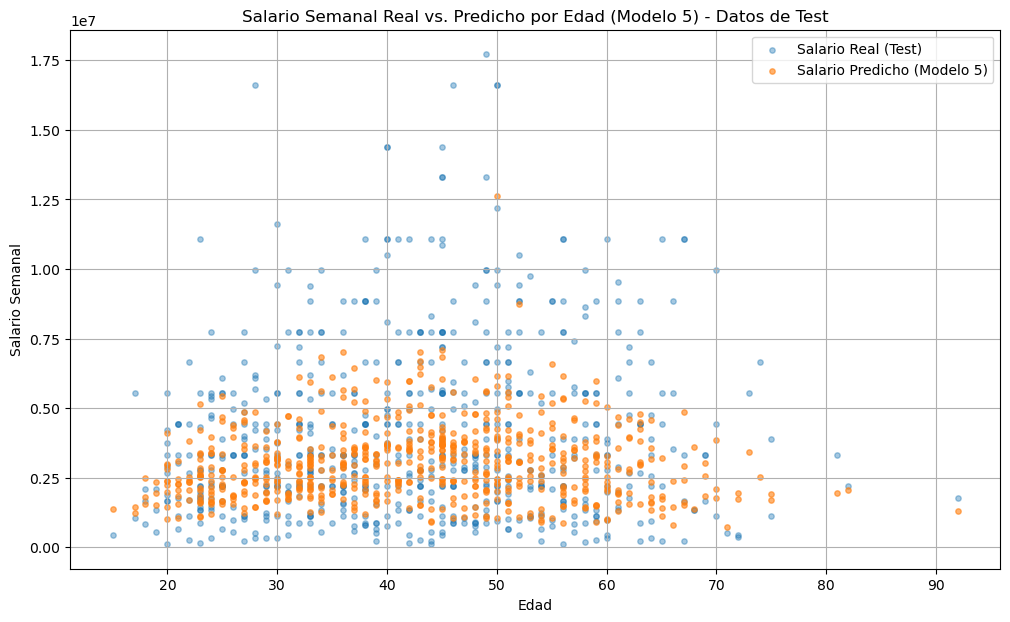


Comentario sobre el gráfico:
El gráfico muestra la relación entre la edad y el salario semanal, comparando los valores reales en el conjunto de test con las predicciones del Modelo 5.
Se observa que las predicciones (puntos naranjas) siguen una tendencia general con la edad, mostrando una forma que refleja la inclusión de 'edad' y 'edad2' en el modelo. La curva de predicción tiende a aplanarse en edades más avanzadas.
Sin embargo, es evidente que las predicciones del modelo son mucho menos dispersas que los salarios reales (puntos azules). El modelo captura la tendencia central o el salario esperado promedio para una persona con ciertas características (edad, educación, género, sector, horas), pero no logra replicar la gran variabilidad individual observada en los salarios reales.
Las predicciones se concentran en una banda relativamente estrecha, mientras que los salarios reales muestran una amplia dispersión, especialmente hacia los valores más altos.


In [32]:
# Asegúrate de tener las bibliotecas necesarias
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from statsmodels.api import add_constant # Asumiendo que usaste statsmodels

# --- Inicio del código para el punto 4 ---

# 1. Identificar el modelo de mejor performance (Modelo 5)
# Asumiendo que modelos_entrenados es una lista donde el Modelo 5 es el último (índice 4)
best_model = modelos_entrenados[4]

# 2. Definir las variables utilizadas por el Modelo 5
vars_model5 = ['edad', 'edad2', 'educ', 'mujer', 'es_trabajador_privado', 'horastrab']
target_var = 'salario_semanal'

# 3. Preparar los datos de test para la predicción, tal como se hizo en la función de evaluación
# Nos aseguramos de que las columnas existan en ocupados_test antes de seleccionarlas
cols_for_model5 = vars_model5 + [target_var]
present_cols_model5 = [col for col in cols_for_model5 if col in ocupados_test.columns]
datos_test_model5 = ocupados_test[present_cols_model5].dropna() # Usamos dropna para tener el mismo N que en la tabla

# Verificar si hay datos después del dropna
if datos_test_model5.empty or target_var not in datos_test_model5.columns:
    print("No hay datos suficientes o la variable objetivo 'salario_semanal' falta en los datos de test después de procesar para el Modelo 5.")
else:
    # Separar variables predictoras y objetivo
    # Usar solo las variables predictoras que existen en los datos procesados
    X_test_vars_model5 = [v for v in vars_model5 if v in datos_test_model5.columns]
    if not X_test_vars_model5:
        print("No se encontraron variables predictoras válidas para el Modelo 5 en los datos de test.")
    else:
        X_test_model5 = add_constant(datos_test_model5[X_test_vars_model5], has_constant='add') # Añadir constante para el intercepto

        y_test_model5 = datos_test_model5[target_var]

        # 4. Realizar la predicción en la escala logarítmica y luego exponenciarla
        y_pred_model5_log = best_model.predict(X_test_model5)
        y_pred_model5 = np.exp(y_pred_model5_log)

        # 5. Crear el gráfico de dispersión
        plt.figure(figsize=(12, 7))

        # Gráfico de dispersión de Salario Real vs Edad
        plt.scatter(datos_test_model5['edad'], y_test_model5, alpha=0.4, label='Salario Real (Test)', s=15)

        # Gráfico de dispersión de Salario Predicho vs Edad
        # Asegurarse de que las edades corresponden a las predicciones
        plt.scatter(datos_test_model5['edad'], y_pred_model5, alpha=0.6, label='Salario Predicho (Modelo 5)', s=15)

        # Etiquetas y título
        plt.xlabel("Edad")
        plt.ylabel("Salario Semanal")
        plt.title("Salario Semanal Real vs. Predicho por Edad (Modelo 5) - Datos de Test")
        plt.legend()
        plt.grid(True)
        plt.show()

        # 6. Comentar brevemente el gráfico
        print("\nComentario sobre el gráfico:")
        print("El gráfico muestra la relación entre la edad y el salario semanal, comparando los valores reales en el conjunto de test con las predicciones del Modelo 5.")
        print("Se observa que las predicciones (puntos naranjas) siguen una tendencia general con la edad, mostrando una forma que refleja la inclusión de 'edad' y 'edad2' en el modelo. La curva de predicción tiende a aplanarse en edades más avanzadas.")
        print("Sin embargo, es evidente que las predicciones del modelo son mucho menos dispersas que los salarios reales (puntos azules). El modelo captura la tendencia central o el salario esperado promedio para una persona con ciertas características (edad, educación, género, sector, horas), pero no logra replicar la gran variabilidad individual observada en los salarios reales.")
        print("Las predicciones se concentran en una banda relativamente estrecha, mientras que los salarios reales muestran una amplia dispersión, especialmente hacia los valores más altos.")
# --- Fin del código para el punto 4 ---

In [33]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from statsmodels.tools.tools import add_constant
from sklearn.metrics import mean_squared_error, mean_absolute_error

def preparar_datos_corregidos(df):
    """Función robusta para preparar los datos"""
    # 1. Verificar y mapear nombres de columnas
    column_mapping = {
        'edad': ['CH06', 'edad'],
        'genero': ['CH04', 'sexo'],
        'educacion': ['CH12', 'nivel_educ'],
        'horas_principal': ['PP3E_TOT', 'horas_trabajo'],
        'horas_secundario': ['PP3F_TOT', 'horas_secundarias'],
        'salario': ['P21', 'ingreso'],
        'sector_trabajo': ['PP04A', 'sector']
    }
    
    # 2. Encontrar los nombres reales de las columnas
    actual_columns = {}
    for standard_name, possible_names in column_mapping.items():
        for name in possible_names:
            if name in df.columns:
                actual_columns[standard_name] = name
                break
        else:
            raise ValueError(f"No se encontró ninguna columna para {standard_name} (posibles nombres: {possible_names})")
    
    # 3. Crear copia del dataframe
    df = df.copy()
    
    # 4. Crear variables necesarias
    try:
        # Edad
        df['edad'] = pd.to_numeric(df[actual_columns['edad']], errors='coerce')
        df['edad2'] = df['edad']**2
        
        # Género (mujer = 1)
        df['mujer'] = (df[actual_columns['genero']] == 2).astype(int)
        
        # Educación (versión simplificada)
        def calcular_educ(row):
            try:
                nivel = int(float(row[actual_columns['educacion']]))
                educ_map = {1:0, 2:3, 3:7, 4:10, 5:12, 6:14, 7:16, 8:16, 9:17, 10:19}
                return educ_map.get(nivel, np.nan)
            except:
                return np.nan
        
        df['educ'] = df.apply(calcular_educ, axis=1)
        
        # Horas trabajadas
        horas_principal = df[actual_columns['horas_principal']].fillna(0)
        horas_secundario = df[actual_columns['horas_secundario']].fillna(0)
        df['horastrab'] = (horas_principal + horas_secundario).clip(1, 168)
        
        # Trabajador del sector privado (PP04A == 2)
        if actual_columns['sector_trabajo'] in df.columns:
            df['es_trabajador_privado'] = (df[actual_columns['sector_trabajo']] == 2).astype(int)
        else:
            df['es_trabajador_privado'] = 1
        
        # Salario semanal (ajustado por inflación)
        ipc_2004 = 4.9
        ipc_2024 = 235.125
        factor_ajuste = ipc_2024 / ipc_2004
        
        df['salario_semanal'] = (pd.to_numeric(df[actual_columns['salario']], errors='coerce') * factor_ajuste) / (52/12)
        
        # Filtrar valores extremos y no positivos
        q_low = df['salario_semanal'].quantile(0.01)
        q_hi = df['salario_semanal'].quantile(0.99)
        df = df[(df['salario_semanal'] > 0) & 
               (df['salario_semanal'] >= q_low) & 
               (df['salario_semanal'] <= q_hi)].copy()
        
        # Transformación logarítmica segura
        df['log_salario'] = np.log(df['salario_semanal'])
        
        return df
    
    except Exception as e:
        raise ValueError(f"Error al procesar los datos: {str(e)}")

def evaluar_modelos_test(modelos_entrenados, test_data):
    """
    Evalúa los modelos en datos de test y genera tabla de métricas
    
    Args:
        modelos_entrenados (list): Lista de modelos statsmodels entrenados
        test_data (DataFrame): Datos de test procesados
        
    Returns:
        DataFrame: Tabla con métricas de performance
    """
    vars_modelos = [
        ['edad'],
        ['edad', 'edad2'],
        ['edad', 'edad2', 'educ'],
        ['edad', 'edad2', 'educ', 'mujer'],
        ['edad', 'edad2', 'educ', 'mujer', 'es_trabajador_privado', 'horastrab']
    ]
    
    metricas = {
        'Modelo': [],
        'MSE test': [],
        'RMSE test': [],
        'MAE test': [],
        'N_test': []
    }
    
    for i, modelo in enumerate(modelos_entrenados, 1):
        try:
            vars_necesarias = vars_modelos[i-1]
            datos_test = test_data[vars_necesarias + ['salario_semanal']].dropna()
            
            if len(datos_test) == 0:
                raise ValueError("No hay datos válidos para evaluar")
                
            X_test = add_constant(datos_test[vars_necesarias])
            y_test = datos_test['salario_semanal']
            y_pred = np.exp(modelo.predict(X_test))
            
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_test, y_pred)
            
            metricas['Modelo'].append(f'({i})')
            metricas['MSE test'].append(f"{mse:.2e}")
            metricas['RMSE test'].append(f"{rmse:,.0f}")
            metricas['MAE test'].append(f"{mae:,.0f}")
            metricas['N_test'].append(len(datos_test))
            
        except Exception as e:
            print(f"Error evaluando Modelo {i}: {str(e)}")
            metricas['Modelo'].append(f'({i})')
            metricas['MSE test'].append(np.nan)
            metricas['RMSE test'].append(np.nan)
            metricas['MAE test'].append(np.nan)
            metricas['N_test'].append(0)
    
    return pd.DataFrame(metricas)

# -----------------------------------------------------------
# EJECUCIÓN PRINCIPAL
# -----------------------------------------------------------

try:
    # 1. Cargar y preparar datos
    print("Preparando datos...")
    
    if 'respondieron' in globals():
        df_principal = respondieron
    elif 'df_gba' in globals():
        df_principal = df_gba
    else:
        raise ValueError("No se encontró ni 'respondieron' ni 'df_gba' en los datos")
    
    # Filtrar solo ocupados (ESTADO == 1)
    if 'ESTADO' not in df_principal.columns:
        raise ValueError("La columna 'ESTADO' no existe para filtrar ocupados")
    
    ocupados = df_principal[df_principal['ESTADO'] == 1].copy()
    
    if len(ocupados) == 0:
        raise ValueError("No hay ocupados en los datos")
    
    # 2. Dividir en train/test (70/30)
    train_data = ocupados.sample(frac=0.7, random_state=444)
    test_data = ocupados.drop(train_data.index)
    
    # 3. Procesar datos de entrenamiento y test
    print("Procesando datos de entrenamiento y test...")
    ocupados_train = preparar_datos_corregidos(train_data)
    ocupados_test = preparar_datos_corregidos(test_data)
    
    # 4. Modelización
    print("Ajustando modelos...")
    modelos_config = [
        ['edad'],
        ['edad', 'edad2'],
        ['edad', 'edad2', 'educ'],
        ['edad', 'edad2', 'educ', 'mujer'],
        ['edad', 'edad2', 'educ', 'mujer', 'es_trabajador_privado', 'horastrab']
    ]

    resultados = []
    modelos_entrenados = []

    for i, vars_modelo in enumerate(modelos_config, 1):
        try:
            # Seleccionar datos y eliminar NA
            datos = ocupados_train[vars_modelo + ['log_salario']].dropna()
            
            if len(datos) < 10:
                print(f"Modelo {i} omitido - solo {len(datos)} observaciones válidas")
                modelos_entrenados.append(None)
                continue
                
            # Ajustar modelo
            X = add_constant(datos[vars_modelo])
            y = datos['log_salario']
            modelo = sm.OLS(y, X).fit()
            modelos_entrenados.append(modelo)
            
            # Preparar resultados
            fila = {'Modelo': f"({i})", 'N': len(datos), 'R2': round(modelo.rsquared, 3)}
            
            for var in ['const'] + vars_modelo:
                coef = modelo.params[var]
                se = modelo.bse[var]
                p = modelo.pvalues[var]
                stars = '***' if p < 0.001 else '**' if p < 0.05 else '*' if p < 0.1 else ''
                fila[var] = f"{coef:.3f}{stars} ({se:.3f})"
            
            resultados.append(fila)
            print(f"Modelo {i} completado exitosamente")
            
        except Exception as e:
            print(f"Error en modelo {i}: {str(e)}")
            modelos_entrenados.append(None)
            continue
    
    # 5. Presentación de resultados entrenamiento
    if resultados:
        columnas = ['Modelo', 'edad', 'edad2', 'educ', 'mujer',
                   'es_trabajador_privado', 'horastrab', 'N', 'R2']
        
        print("\n" + "="*80)
        print("Tabla 2. Estimación por regresión lineal de salarios usando la base de entrenamiento")
        print("Var. Dep: log(salario_semanal)")
        print("Nota: * p<0.1, ** p<0.05, *** p<0.001")
        print("="*80)
        
        tabla_final = pd.DataFrame(resultados, columns=columnas)
        print(tabla_final.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
        
        # Estadísticas descriptivas
        print("\nEstadísticas descriptivas:")
        print(f"- Muestra final: {len(ocupados_train)} ocupados en entrenamiento")
        print(f"- Salario semanal promedio: ${ocupados_train['salario_semanal'].mean():,.2f}")
        print(f"- Edad promedio: {ocupados_train['edad'].mean():.1f} años")
        print(f"- Porcentaje de mujeres: {ocupados_train['mujer'].mean()*100:.1f}%")
        print(f"- Porcentaje en sector privado: {ocupados_train['es_trabajador_privado'].mean()*100:.1f}%")
    else:
        print("No se pudo calcular ningún modelo debido a errores en los datos")
    
    # 6. Evaluación en test
    if modelos_entrenados and any(modelos_entrenados):
        print("\n" + "="*80)
        print("Evaluando modelos en datos de test...")
        tabla_performance = evaluar_modelos_test(modelos_entrenados, ocupados_test)
        
        print("\n" + "="*80)
        print("Tabla 3. Performance por regresión lineal de la predicción de salarios")
        print("Variable Dependiente: salario_semanal")
        print("="*80)
        print(tabla_performance.to_string(index=False))
        
        # Análisis adicional
        mejor_modelo_idx = tabla_performance['RMSE test'].astype(str).str.replace(',', '').astype(float).idxmin()
        print(f"\nMejor modelo: Modelo {mejor_modelo_idx + 1} con RMSE = {tabla_performance.loc[mejor_modelo_idx, 'RMSE test']}")

except Exception as e:
    print(f"\nERROR CRÍTICO: {str(e)}")
    print("Posibles soluciones:")
    print("1. Verificar que las columnas CH06, CH12, P21, PP04A existan en tus datos")
    print("2. Revisar que el dataframe 'respondieron' o 'df_gba' esté correctamente cargado")
    print("3. Asegurarse de que hay suficientes datos (filas) para el análisis")

Preparando datos...
Procesando datos de entrenamiento y test...
Ajustando modelos...
Modelo 1 completado exitosamente
Modelo 2 completado exitosamente
Modelo 3 completado exitosamente
Modelo 4 completado exitosamente
Modelo 5 completado exitosamente

Tabla 2. Estimación por regresión lineal de salarios usando la base de entrenamiento
Var. Dep: log(salario_semanal)
Nota: * p<0.1, ** p<0.05, *** p<0.001
Modelo             edad             edad2             educ             mujer es_trabajador_privado        horastrab    N    R2
   (1)    0.001 (0.002)               NaN              NaN               NaN                   NaN              NaN 1504 0.000
   (2) 0.059*** (0.010) -0.001*** (0.000)              NaN               NaN                   NaN              NaN 1504 0.024
   (3) 0.062*** (0.009) -0.001*** (0.000) 0.069*** (0.006)               NaN                   NaN              NaN 1502 0.109
   (4) 0.066*** (0.009) -0.001*** (0.000) 0.078*** (0.006) -0.510*** (0.044)           